# Baseline IDS Analysis — CICIDS2023


This notebook covers:
- Dataset exploration and class distribution
- Data preprocessing (encoding, NaN handling, infinite value removal)
- Binary classification: Normal vs Attack
- Multi-class classification across all attack types
- Feature importance analysis
- Baseline results for comparison against adaptive model

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay, f1_score,
    balanced_accuracy_score
)

plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 2. Load Dataset

In [2]:
# Targeted loading: keep ALL rare class rows + sample common classes from each file
# This ensures rare classes (SQL, XSS, etc.) are always captured
csv_files = sorted(glob.glob('../datasets/cicids2023/Merged*.csv'))[:10]

RARE_CLASSES = [
    'SQLINJECTION', 'UPLOADING_ATTACK', 'XSS',
    'COMMANDINJECTION', 'BACKDOOR_MALWARE', 'BROWSERHIJACKING',
    'DICTIONARYBRUTEFORCE', 'RECON-PINGSWEEP'
]
COMMON_SAMPLE = 2000  # rows per file from common classes

dfs = []
for f in csv_files:
    df_full = pd.read_csv(f)
    rare_mask = df_full['Label'].isin(RARE_CLASSES)
    df_rare   = df_full[rare_mask]
    df_common = df_full[~rare_mask].sample(
        n=min(COMMON_SAMPLE, (~rare_mask).sum()), random_state=42
    )
    dfs.append(pd.concat([df_rare, df_common], ignore_index=True))

df = pd.concat(dfs, ignore_index=True)
print(f'Files loaded : {len(csv_files)}')
print(f'Total rows   : {len(df):,}')
print('Missing values:', df.isnull().sum().sum())
print('\nRare class counts in loaded data:')
lc = df['Label'].value_counts()
for cls in RARE_CLASSES:
    print(f'  {cls}: {lc.get(cls, 0)}')

Files loaded : 10
Total rows   : 26,336
Missing values: 2

Rare class counts in loaded data:
  SQLINJECTION: 822
  UPLOADING_ATTACK: 220
  XSS: 645
  COMMANDINJECTION: 810
  BACKDOOR_MALWARE: 487
  BROWSERHIJACKING: 924
  DICTIONARYBRUTEFORCE: 2081
  RECON-PINGSWEEP: 347


## 3. Exploratory Data Analysis

Class distribution:
Label
DDOS-ICMP_FLOOD            3096
DDOS-UDP_FLOOD             2341
DICTIONARYBRUTEFORCE       2081
DDOS-TCP_FLOOD             1870
DDOS-RSTFINFLOOD           1726
DDOS-SYN_FLOOD             1717
DDOS-PSHACK_FLOOD          1693
DDOS-SYNONYMOUSIP_FLOOD    1548
DOS-UDP_FLOOD              1424
DOS-TCP_FLOOD              1111
BROWSERHIJACKING            924
DOS-SYN_FLOOD               878
SQLINJECTION                822
COMMANDINJECTION            810
XSS                         645
BACKDOOR_MALWARE            487
BENIGN                      464
MIRAI-GREETH_FLOOD          426
MIRAI-UDPPLAIN              391
RECON-PINGSWEEP             347
MIRAI-GREIP_FLOOD           326
UPLOADING_ATTACK            220
DDOS-ICMP_FRAGMENTATION     190
VULNERABILITYSCAN           160
MITM-ARPSPOOFING            143
DDOS-UDP_FRAGMENTATION      130
DDOS-ACK_FRAGMENTATION      108
DNS_SPOOFING                 78
RECON-HOSTDISCOVERY          63
RECON-OSSCAN                 36
DOS-HTTP_FLOOD

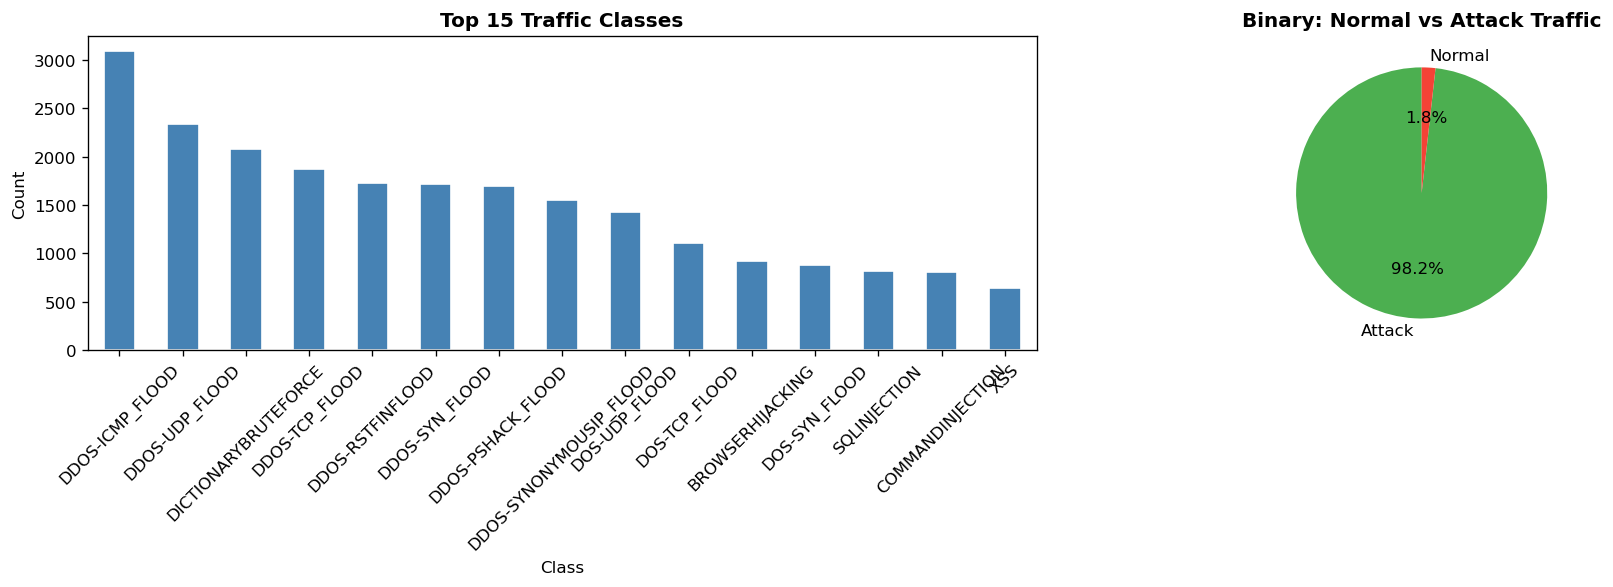

In [3]:
label_counts = df['Label'].value_counts()
print('Class distribution:')
print(label_counts.to_string())
print(f'\nTotal classes: {len(label_counts)}')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

label_counts.head(15).plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Top 15 Traffic Classes', fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

df['Binary_Label'] = df['Label'].apply(lambda x: 'Normal' if x == 'BENIGN' else 'Attack')
binary_counts = df['Binary_Label'].value_counts()
axes[1].pie(binary_counts, labels=binary_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50', '#F44336'], startangle=90)
axes[1].set_title('Binary: Normal vs Attack Traffic', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/class_distribution.png', bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [4]:
df_clean = df.copy()

# Remove NaN and infinite values
df_clean = df_clean.dropna()
df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
df_clean = df_clean.dropna()
print(f'After NaN removal: {df_clean.shape}')

# Drop classes with fewer than 2 samples (minimum needed for stratified split)
class_counts = df_clean['Label'].value_counts()
valid_classes = class_counts[class_counts >= 2].index
removed = class_counts[class_counts < 2].index.tolist()
if removed:
    print(f'Removing {len(removed)} class(es) with < 2 samples: {removed}')
else:
    print('No classes removed — all classes have sufficient samples')
df_clean = df_clean[df_clean['Label'].isin(valid_classes)].copy()
print(f'Clean dataset shape: {df_clean.shape}')

# Show rare class counts to confirm SQL Injection and UPLOADING_ATTACK are present
print('\nRare class sample counts:')
for cls in ['SQLINJECTION', 'UPLOADING_ATTACK', 'XSS', 'COMMANDINJECTION', 'BACKDOOR_MALWARE']:
    print(f'  {cls}: {class_counts.get(cls, 0)}')

# Multi-class label encoding
encoder = LabelEncoder()
df_clean['Label_encoded'] = encoder.fit_transform(df_clean['Label'])
print(f'\nClasses ({len(encoder.classes_)}): {list(encoder.classes_)}')

# Binary label encoding
df_clean['Binary_encoded'] = (df_clean['Binary_Label'] == 'Attack').astype(int)

# Feature matrix
feature_cols = [c for c in df_clean.columns
                if c not in ['Label', 'Binary_Label', 'Label_encoded', 'Binary_encoded']]
X = df_clean[feature_cols]
print(f'Features: {len(feature_cols)}')

After NaN removal: (26335, 41)
No classes removed — all classes have sufficient samples
Clean dataset shape: (26335, 41)

Rare class sample counts:
  SQLINJECTION: 822
  UPLOADING_ATTACK: 220
  XSS: 645
  COMMANDINJECTION: 810
  BACKDOOR_MALWARE: 487

Classes (34): ['BACKDOOR_MALWARE', 'BENIGN', 'BROWSERHIJACKING', 'COMMANDINJECTION', 'DDOS-ACK_FRAGMENTATION', 'DDOS-HTTP_FLOOD', 'DDOS-ICMP_FLOOD', 'DDOS-ICMP_FRAGMENTATION', 'DDOS-PSHACK_FLOOD', 'DDOS-RSTFINFLOOD', 'DDOS-SLOWLORIS', 'DDOS-SYNONYMOUSIP_FLOOD', 'DDOS-SYN_FLOOD', 'DDOS-TCP_FLOOD', 'DDOS-UDP_FLOOD', 'DDOS-UDP_FRAGMENTATION', 'DICTIONARYBRUTEFORCE', 'DNS_SPOOFING', 'DOS-HTTP_FLOOD', 'DOS-SYN_FLOOD', 'DOS-TCP_FLOOD', 'DOS-UDP_FLOOD', 'MIRAI-GREETH_FLOOD', 'MIRAI-GREIP_FLOOD', 'MIRAI-UDPPLAIN', 'MITM-ARPSPOOFING', 'RECON-HOSTDISCOVERY', 'RECON-OSSCAN', 'RECON-PINGSWEEP', 'RECON-PORTSCAN', 'SQLINJECTION', 'UPLOADING_ATTACK', 'VULNERABILITYSCAN', 'XSS']
Features: 39


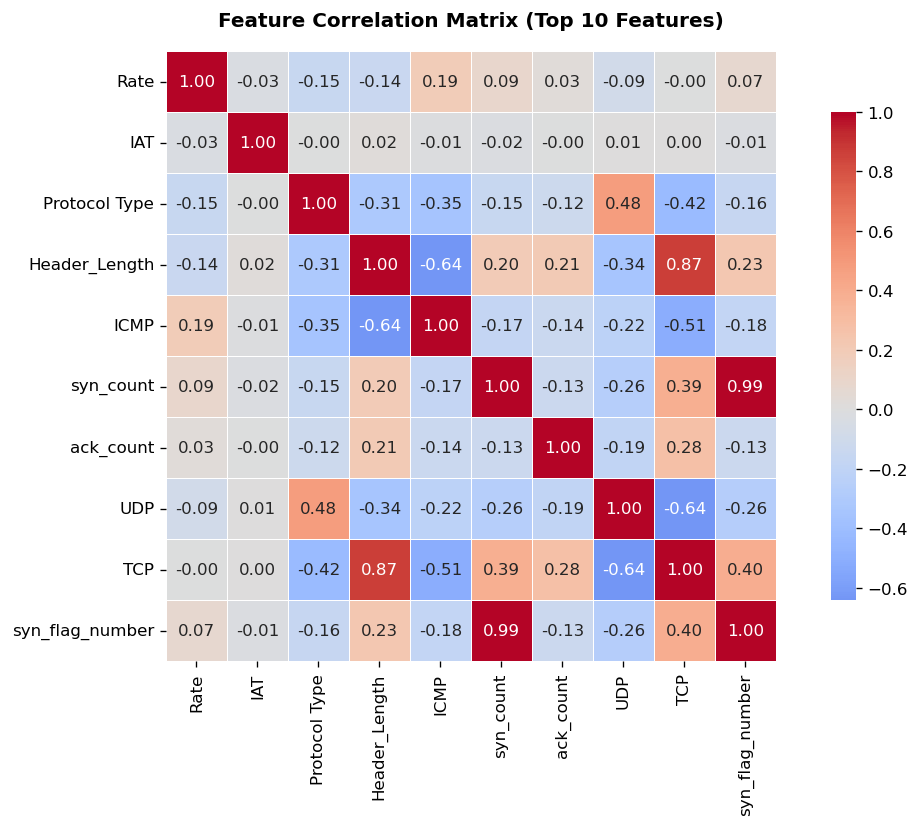

In [5]:
# Feature correlation heatmap
top_features = ['Rate', 'IAT', 'Protocol Type', 'Header_Length', 'ICMP',
                'syn_count', 'ack_count', 'UDP', 'TCP', 'syn_flag_number']

plt.figure(figsize=(10, 7))
corr = df_clean[top_features].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation Matrix (Top 10 Features)', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../results/feature_correlation.png', bbox_inches='tight')
plt.show()

## 5. Binary Classification — Normal vs Attack

In [6]:
y_binary = df_clean['Binary_encoded']
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)
print(f'Train: {len(X_train_b)}  |  Test: {len(X_test_b)}')

rf_binary = RandomForestClassifier(n_estimators=100, random_state=42,
                                    n_jobs=-1, class_weight='balanced')
rf_binary.fit(X_train_b, y_train_b)

y_pred_b = rf_binary.predict(X_test_b)
acc_b     = accuracy_score(y_test_b, y_pred_b)
f1_b      = f1_score(y_test_b, y_pred_b, average='weighted')
bal_acc_b = balanced_accuracy_score(y_test_b, y_pred_b)

print(f'\nBinary Classification Results')
print(f'Accuracy          : {acc_b:.4f} ({acc_b*100:.2f}%)')
print(f'Balanced Accuracy : {bal_acc_b:.4f} ({bal_acc_b*100:.2f}%)')
print(f'F1 Score (weighted): {f1_b:.4f}')
print()
print(classification_report(y_test_b, y_pred_b,
                             target_names=['Normal', 'Attack'], zero_division=0))

Train: 21068  |  Test: 5267

Binary Classification Results
Accuracy          : 0.9842 (98.42%)
Balanced Accuracy : 0.6118 (61.18%)
F1 Score (weighted): 0.9804

              precision    recall  f1-score   support

      Normal       0.66      0.23      0.34        93
      Attack       0.99      1.00      0.99      5174

    accuracy                           0.98      5267
   macro avg       0.82      0.61      0.66      5267
weighted avg       0.98      0.98      0.98      5267



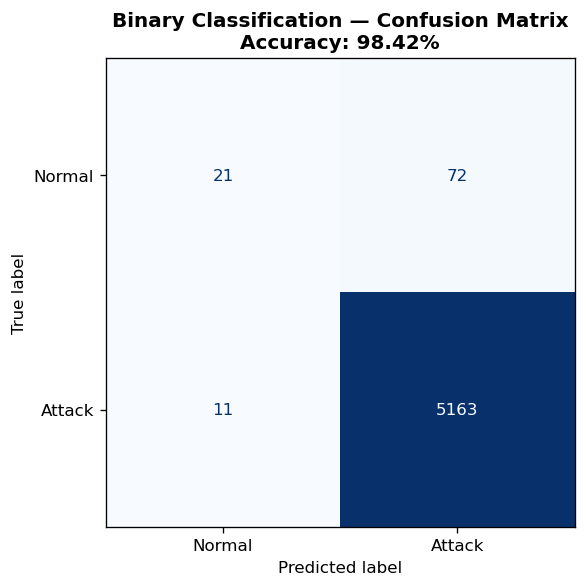

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
cm_b = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_b, display_labels=['Normal', 'Attack'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Binary Classification — Confusion Matrix\nAccuracy: {acc_b*100:.2f}%',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../results/binary_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 6. Multi-Class Classification — All Attack Types

In [8]:
y_multi = df_clean['Label_encoded']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X, y_multi, test_size=0.2, random_state=42, stratify=y_multi
)

rf_multi = RandomForestClassifier(n_estimators=100, random_state=42,
                                   n_jobs=-1, class_weight='balanced')
rf_multi.fit(X_train_m, y_train_m)

y_pred_m  = rf_multi.predict(X_test_m)
acc_m     = accuracy_score(y_test_m, y_pred_m)
f1_macro  = f1_score(y_test_m, y_pred_m, average='macro',    zero_division=0)
f1_w      = f1_score(y_test_m, y_pred_m, average='weighted', zero_division=0)
bal_acc_m = balanced_accuracy_score(y_test_m, y_pred_m)

print('Multi-Class Results (with class_weight=balanced)')
print(f'Accuracy          : {acc_m:.4f} ({acc_m*100:.2f}%)')
print(f'Balanced Accuracy : {bal_acc_m:.4f} ({bal_acc_m*100:.2f}%)')
print(f'Macro F1 Score    : {f1_macro:.4f}   <-- headline metric')
print(f'Weighted F1 Score : {f1_w:.4f}')
print()
print(classification_report(y_test_m, y_pred_m,
                             target_names=encoder.classes_, zero_division=0))

Multi-Class Results (with class_weight=balanced)
Accuracy          : 0.6687 (66.87%)
Balanced Accuracy : 0.5297 (52.97%)
Macro F1 Score    : 0.5418   <-- headline metric
Weighted F1 Score : 0.6582

                         precision    recall  f1-score   support

       BACKDOOR_MALWARE       0.24      0.14      0.18        97
                 BENIGN       0.51      0.37      0.42        93
       BROWSERHIJACKING       0.53      0.49      0.51       185
       COMMANDINJECTION       0.46      0.40      0.43       162
 DDOS-ACK_FRAGMENTATION       1.00      0.91      0.95        22
        DDOS-HTTP_FLOOD       0.50      0.67      0.57         3
        DDOS-ICMP_FLOOD       1.00      1.00      1.00       619
DDOS-ICMP_FRAGMENTATION       1.00      0.89      0.94        38
      DDOS-PSHACK_FLOOD       0.99      1.00      0.99       339
       DDOS-RSTFINFLOOD       1.00      1.00      1.00       345
         DDOS-SLOWLORIS       0.00      0.00      0.00         2
DDOS-SYNONYMOUSIP_FLO

## 7. Feature Importance

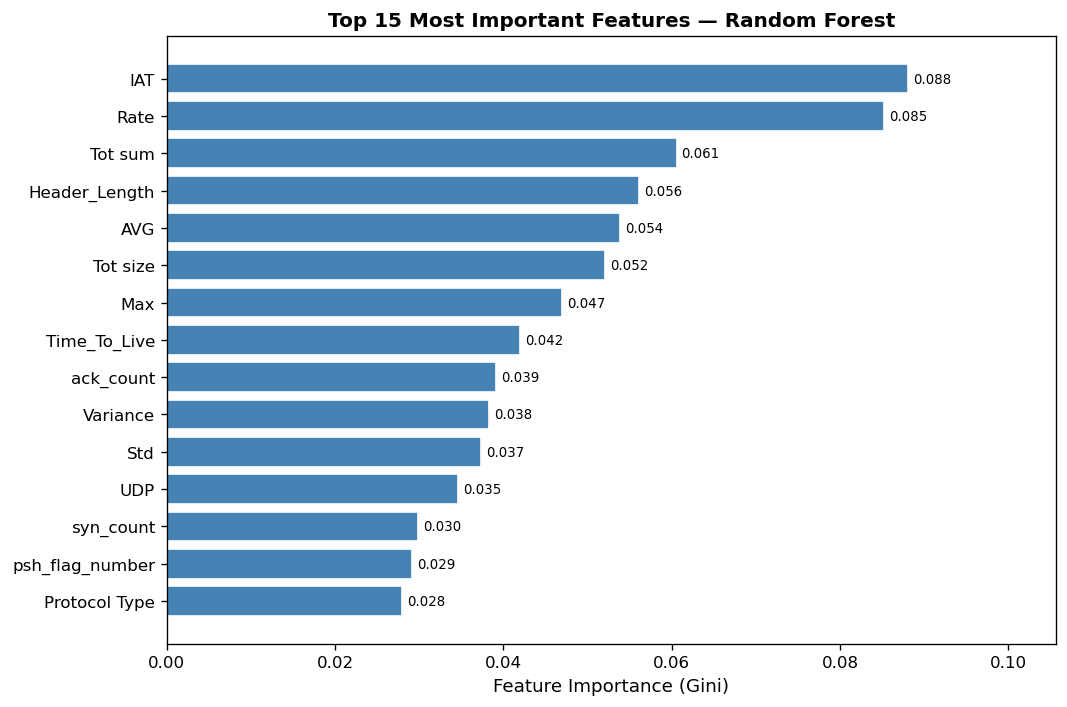

Top 5 features:
      Feature  Importance
          IAT    0.088058
         Rate    0.085218
      Tot sum    0.060584
Header_Length    0.056132
          AVG    0.053865


In [9]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_multi.feature_importances_
}).sort_values('Importance', ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'],
               color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)', fontsize=11)
ax.set_title('Top 15 Most Important Features — Random Forest', fontweight='bold', fontsize=12)
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=8)
ax.set_xlim(0, importance_df['Importance'].max() * 1.2)
plt.tight_layout()
plt.savefig('../results/feature_importance.png', bbox_inches='tight')
plt.show()

print('Top 5 features:')
print(importance_df.tail(5)[['Feature','Importance']].iloc[::-1].to_string(index=False))

## 8. Baseline Results Summary

In [10]:
print('         BASELINE MODEL RESULTS SUMMARY (FIXED)')
print(f'Dataset          : CICIoT2023 — {len(csv_files)} files x 5,000 rows')
print(f'Total Samples    : {len(df_clean):,}')
print(f'Features         : {len(feature_cols)}')
print(f'Classes          : {len(encoder.classes_)}')
print(f'class_weight     : balanced')
print()
print(f'Binary  Accuracy          : {acc_b*100:.2f}%')
print(f'Binary  Balanced Accuracy : {bal_acc_b*100:.2f}%')
print(f'Binary  F1 (weighted)     : {f1_b:.4f}')
print()
print(f'Multi   Accuracy          : {acc_m*100:.2f}%')
print(f'Multi   Balanced Accuracy : {bal_acc_m*100:.2f}%')
print(f'Multi   Macro F1          : {f1_macro:.4f}   <-- main metric')
print(f'Multi   Weighted F1       : {f1_w:.4f}')

         BASELINE MODEL RESULTS SUMMARY (FIXED)
Dataset          : CICIoT2023 — 10 files x 5,000 rows
Total Samples    : 26,335
Features         : 39
Classes          : 34
class_weight     : balanced

Binary  Accuracy          : 98.42%
Binary  Balanced Accuracy : 61.18%
Binary  F1 (weighted)     : 0.9804

Multi   Accuracy          : 66.87%
Multi   Balanced Accuracy : 52.97%
Multi   Macro F1          : 0.5418   <-- main metric
Multi   Weighted F1       : 0.6582
